# Delivery Operations Analytics: Last-Mile Delivery Performance & Slow-Delivery Analysis

This project analyzes delivery operations data to understand what factors are linked with longer delivery times.

The focus is on practical analyst work:
- checking data quality
- creating useful delivery features
- building operational KPIs
- identifying slow-delivery risk groups
- preparing dashboard-ready outputs

A small baseline model is included only as a supporting check, not as the main objective.

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

sns.set_style("whitegrid")

In [2]:
data_paths = [
    "../data/raw/amazon_delivery.csv",
    "../data/amazon_delivery_raw.csv",
    "amazon_delivery.csv"
]

file_path = next((path for path in data_paths if os.path.exists(path)), None)

if file_path is None:
    raise FileNotFoundError("Dataset file not found. Place amazon_delivery.csv in data/raw or the current folder.")

df = pd.read_csv(file_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 43,739
Columns: 16


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11.30.00,11.45.00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19.45.00,19.50.00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8.30.00,8.45.00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18.00.00,18.10.00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13.30.00,13.45.00,Cloudy,High,scooter,Metropolitian,150,Toys


## Initial Data Review

I first reviewed the structure of the dataset before making changes.

The checks below help understand:
- available columns
- data types
- missing values
- duplicate records
- basic value ranges

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,43739,43739,ialx566343618,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agent_Age,43739.0,NaN,NaN,NaN,29.567137,5.815155,15.0,25.0,30.0,35.0,50.0
Agent_Rating,43685.0,NaN,NaN,NaN,4.63378,0.334716,1.0,4.5,4.7,4.9,6.0
Store_Latitude,43739.0,NaN,NaN,NaN,17.21096,7.764225,-30.902872,12.933298,18.55144,22.732225,30.914057
Store_Longitude,43739.0,NaN,NaN,NaN,70.661177,21.475005,-88.366217,73.170283,75.898497,78.045359,88.433452
Drop_Latitude,43739.0,NaN,NaN,NaN,17.459031,7.34295,0.01,12.985996,18.633626,22.785049,31.054057
Drop_Longitude,43739.0,NaN,NaN,NaN,70.821842,21.153148,0.01,73.28,76.002574,78.104095,88.563452
Order_Date,43739,44,15-03-2022,1141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Time,43739,177,21.55.00,460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup_Time,43739,193,21.30.00,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

if "order_id" not in df.columns:
    df["order_id"] = np.arange(1, len(df) + 1)

df.columns.tolist()

['order_id',
 'agent_age',
 'agent_rating',
 'store_latitude',
 'store_longitude',
 'drop_latitude',
 'drop_longitude',
 'order_date',
 'order_time',
 'pickup_time',
 'weather',
 'traffic',
 'vehicle',
 'area',
 'delivery_time',
 'category']

In [6]:
missing_summary = (
    df.isna().sum()
    .reset_index()
    .rename(columns={"index": "column_name", 0: "missing_count"})
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

missing_summary.sort_values("missing_count", ascending=False)

Duplicate rows: 0


,column_name,missing_count,missing_percentage
10,weather,91,0.21
2,agent_rating,54,0.12
1,agent_age,0,0.00
0,order_id,0,0.00
4,store_longitude,0,0.00
5,drop_latitude,0,0.00
6,drop_longitude,0,0.00
3,store_latitude,0,0.00
7,order_date,0,0.00
8,order_time,0,0.00


In [7]:
if duplicate_rows > 0:
    df = df.drop_duplicates()

text_columns = ["weather", "traffic", "vehicle", "area", "category"]
text_columns = [col for col in text_columns if col in df.columns]

for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
        .replace({"Nan": "Unknown", "None": "Unknown", "Null": "Unknown", "": "Unknown"})
    )

numeric_columns = [
    "agent_age",
    "agent_rating",
    "delivery_time",
    "store_latitude",
    "store_longitude",
    "drop_latitude",
    "drop_longitude"
]

numeric_columns = [col for col in numeric_columns if col in df.columns]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if "agent_rating" in df.columns:
    df.loc[df["agent_rating"] > 5, "agent_rating"] = np.nan
    df["agent_rating"] = df["agent_rating"].fillna(df["agent_rating"].median())

## Feature Engineering

I created features that are useful for delivery operations analysis.

The main additions are:
- order hour and weekend flag
- pickup delay
- delivery distance
- distance quality flag
- distance category
- peak-hour flag
- agent rating group
- proxy slow-delivery flag

Some assumptions are used because the dataset does not include actual SLA or promised delivery time.

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce", dayfirst=True)

df["order_time"] = df["order_time"].astype(str).str.strip().str.replace(".", ":", regex=False)
df["pickup_time"] = df["pickup_time"].astype(str).str.strip().str.replace(".", ":", regex=False)

df["order_day"] = df["order_date"].dt.day_name()
df["order_month"] = df["order_date"].dt.month
df["is_weekend"] = df["order_day"].isin(["Saturday", "Sunday"])

df["order_hour"] = pd.to_datetime(
    df["order_time"],
    format="%H:%M:%S",
    errors="coerce"
).dt.hour

df[["order_date", "order_day", "order_hour", "is_weekend"]].head()

,order_date,order_day,order_hour,is_weekend
0,2022-03-19,Saturday,11.0,True
1,2022-03-25,Friday,19.0,False
2,2022-03-19,Saturday,8.0,True
3,2022-04-05,Tuesday,18.0,False
4,2022-03-26,Saturday,13.0,True


In [9]:
order_time = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors="coerce")
pickup_time = pd.to_datetime(df["pickup_time"], format="%H:%M:%S", errors="coerce")

df["pickup_delay_mins"] = (pickup_time - order_time).dt.total_seconds() / 60
df.loc[df["pickup_delay_mins"] < 0, "pickup_delay_mins"] = np.nan

print("Missing pickup delay:", df["pickup_delay_mins"].isna().sum())
print("Average pickup delay:", round(df["pickup_delay_mins"].mean(), 2))

Missing pickup delay: 919
Average pickup delay: 9.96


Some pickup delay values became missing because the time fields could not be parsed properly or pickup time appeared earlier than order time.

Orders crossing midnight may also create negative pickup delay because the dataset does not provide a separate pickup date.

I did not remove these rows because they can still be used for delivery-time, traffic, weather, vehicle, and area-level analysis.

In [10]:
def haversine_distance(lat1, lon1, lat2, lon2):
    radius = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    value = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * radius * np.arcsin(np.sqrt(value))


df["distance_km"] = haversine_distance(
    df["store_latitude"],
    df["store_longitude"],
    df["drop_latitude"],
    df["drop_longitude"]
).round(2)

df["distance_issue_flag"] = np.where(
    (df["distance_km"] > 30) | (df["distance_km"].isna()),
    1,
    0
)

print("Average distance before filtering:", round(df["distance_km"].mean(), 2), "km")
print("Distance issue records:", df["distance_issue_flag"].sum())

Average distance before filtering: 38.56 km
Distance issue records: 188


In [11]:
def distance_group(row):
    if row["distance_issue_flag"] == 1:
        return "Distance Issue"
    if pd.isna(row["distance_km"]):
        return "Unknown"
    if row["distance_km"] <= 5:
        return "Short"
    if row["distance_km"] <= 10:
        return "Medium"
    if row["distance_km"] <= 15:
        return "Long"
    return "Very Long"


df["distance_category"] = df.apply(distance_group, axis=1)

df[["distance_km", "distance_issue_flag", "distance_category"]].head()


,distance_km,distance_issue_flag,distance_category
0,3.03,0,Short
1,20.18,0,Very Long
2,1.55,0,Short
3,7.79,0,Medium
4,6.21,0,Medium


In [12]:
df["peak_hour_flag"] = np.select(
    [
        df["order_hour"].isna(),
        df["order_hour"].between(17, 22)
    ],
    [
        "Unknown",
        "Peak Hour"
    ],
    default="Non-Peak Hour"
)

df["peak_hour_flag"].value_counts(dropna=False)


peak_hour_flag
Peak Hour        27018
Non-Peak Hour    16630
Unknown             91
Name: count, dtype: int64

In [13]:
def rating_group(rating):
    if pd.isna(rating):
        return "Unknown"
    if rating < 4.5:
        return "Low Rating"
    if rating < 4.8:
        return "Medium Rating"
    return "High Rating"


df["rating_group"] = df["agent_rating"].apply(rating_group)

df["rating_group"].value_counts(dropna=False)


rating_group
High Rating      18185
Medium Rating    17492
Low Rating        8062
Name: count, dtype: int64

In [14]:
slow_limit = df["delivery_time"].quantile(0.75)

df["slow_delivery_flag"] = (df["delivery_time"] > slow_limit).astype(int)

analysis_df = df[df["distance_issue_flag"] == 0].copy()

print("Slow delivery threshold:", round(slow_limit, 2))
print("Slow delivery rate:", round(df["slow_delivery_flag"].mean() * 100, 2), "%")
print("Rows in full dataset:", len(df))
print("Rows used for distance-based analysis:", len(analysis_df))

Slow delivery threshold: 160.0
Slow delivery rate: 23.05 %
Rows in full dataset: 43739
Rows used for distance-based analysis: 43551


## Slow-Delivery Assumption

The dataset does not provide promised delivery time or SLA target.

Because of that, slow delivery is treated as a proxy metric. Orders above the 75th percentile of delivery time are marked as slow-delivery cases.

This should not be interpreted as an actual company-defined delay.

In [15]:
kpi_summary = pd.DataFrame({
    "metric": [
        "total_orders",
        "avg_delivery_time",
        "median_delivery_time",
        "avg_distance_km_clean_records",
        "avg_pickup_delay_mins",
        "slow_delivery_threshold",
        "slow_delivery_rate",
        "distance_issue_records"
    ],
    "value": [
        len(df),
        round(df["delivery_time"].mean(), 2),
        round(df["delivery_time"].median(), 2),
        round(analysis_df["distance_km"].mean(), 2),
        round(df["pickup_delay_mins"].mean(), 2),
        round(slow_limit, 2),
        round(df["slow_delivery_flag"].mean() * 100, 2),
        int(df["distance_issue_flag"].sum())
    ]
})

kpi_summary

,metric,value
0,total_orders,43739.00
1,avg_delivery_time,124.91
2,median_delivery_time,125.00
3,avg_distance_km_clean_records,9.73
4,avg_pickup_delay_mins,9.96
5,slow_delivery_threshold,160.00
6,slow_delivery_rate,23.05
7,distance_issue_records,188.00


## Delivery Performance Analysis

The analysis below focuses on a few practical questions:

- How is delivery time distributed?
- Which traffic groups have higher delivery time?
- Does distance category change slow-delivery risk?
- Which traffic and distance combinations are riskier?
- How do hourly, vehicle, and rating groups perform?

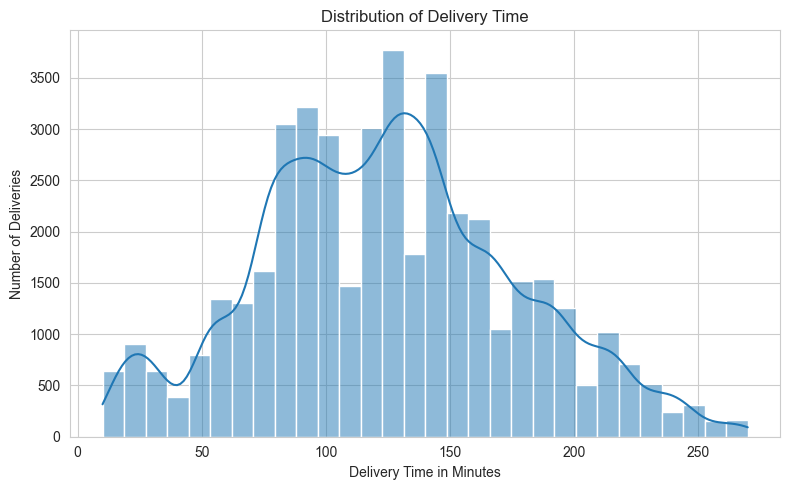

Records above 200 minutes: 3611


In [16]:
os.makedirs("../visuals", exist_ok=True)

plt.figure(figsize=(8, 5))
sns.histplot(df["delivery_time"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time in Minutes")
plt.ylabel("Number of Deliveries")
plt.tight_layout()
plt.savefig("../visuals/delivery_time_distribution.png", dpi=300)
plt.show()

print("Records above 200 minutes:", len(df[df["delivery_time"] > 200]))

,traffic,orders,avg_delivery_time,median_delivery_time,slow_delivery_rate
1,Jam,13725,147.76,150.0,41.01
0,High,4296,129.42,135.0,22.84
3,Medium,10628,126.84,130.0,24.05
4,Unknown,91,120.67,125.0,15.38
2,Low,14999,101.35,100.0,6.03


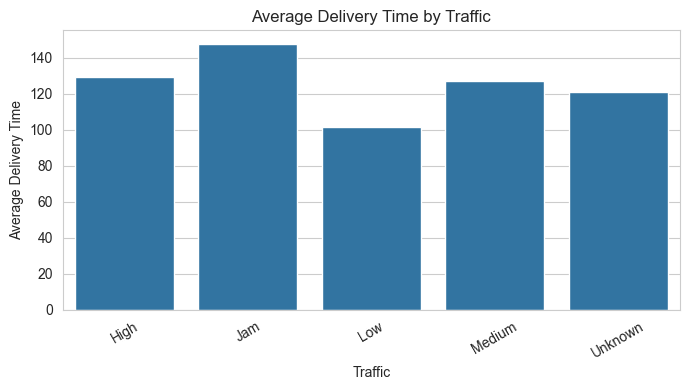

In [17]:
traffic_summary = (
    df.groupby("traffic")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        median_delivery_time=("delivery_time", "median"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

traffic_summary["avg_delivery_time"] = traffic_summary["avg_delivery_time"].round(2)
traffic_summary["median_delivery_time"] = traffic_summary["median_delivery_time"].round(2)
traffic_summary["slow_delivery_rate"] = (traffic_summary["slow_delivery_rate"] * 100).round(2)

display(traffic_summary.sort_values("avg_delivery_time", ascending=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=traffic_summary, x="traffic", y="avg_delivery_time")
plt.title("Average Delivery Time by Traffic")
plt.xlabel("Traffic")
plt.ylabel("Average Delivery Time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../visuals/avg_delivery_time_by_traffic.png", dpi=300)
plt.show()

,distance_category,orders,avg_distance_km,avg_delivery_time,slow_delivery_rate
2,Short,11722,3.06,105.37,7.96
1,Medium,11759,7.66,115.47,13.62
0,Long,11754,12.25,141.90,37.56
3,Very Long,8316,18.52,141.89,37.35


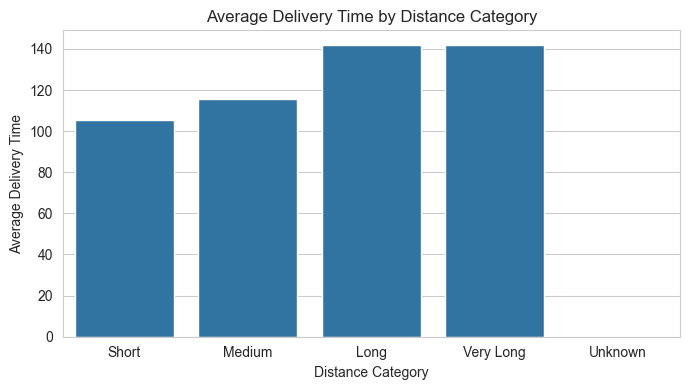

In [18]:
distance_summary = (
    analysis_df.groupby("distance_category")
    .agg(
        orders=("order_id", "count"),
        avg_distance_km=("distance_km", "mean"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

distance_summary["avg_distance_km"] = distance_summary["avg_distance_km"].round(2)
distance_summary["avg_delivery_time"] = distance_summary["avg_delivery_time"].round(2)
distance_summary["slow_delivery_rate"] = (distance_summary["slow_delivery_rate"] * 100).round(2)

distance_order = ["Short", "Medium", "Long", "Very Long", "Unknown"]
distance_summary["distance_category"] = pd.Categorical(
    distance_summary["distance_category"],
    categories=distance_order,
    ordered=True
)

distance_summary = distance_summary.sort_values("distance_category")

display(distance_summary)

plt.figure(figsize=(7, 4))
sns.barplot(data=distance_summary, x="distance_category", y="avg_delivery_time")
plt.title("Average Delivery Time by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Average Delivery Time")
plt.tight_layout()
plt.savefig("../visuals/delivery_time_by_distance_category.png", dpi=300)
plt.show()

,traffic,distance_category,orders,avg_delivery_time,slow_delivery_rate
5,Jam,Very Long,3600,159.18,52.42
2,Jam,Long,5081,159.05,52.25
10,Medium,Long,3342,142.66,39.02
13,Medium,Very Long,2316,142.28,37.69
0,High,Medium,2341,129.79,23.24
1,High,Short,1938,128.92,22.39
3,Jam,Medium,3399,128.11,21.68
4,Jam,Short,1598,128.20,21.21
9,Low,Very Long,2388,115.45,14.32
6,Low,Long,3314,114.96,13.64


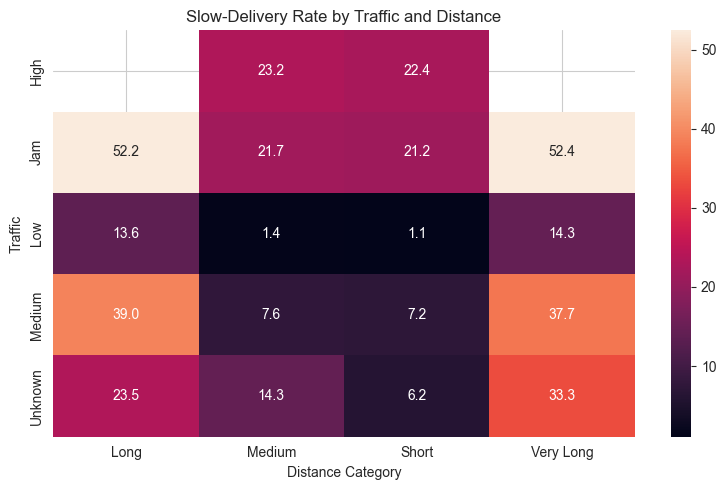

In [19]:
traffic_distance = (
    analysis_df.groupby(["traffic", "distance_category"])
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

traffic_distance["avg_delivery_time"] = traffic_distance["avg_delivery_time"].round(2)
traffic_distance["slow_delivery_rate"] = (traffic_distance["slow_delivery_rate"] * 100).round(2)

display(
    traffic_distance
    .query("orders >= 50")
    .sort_values("slow_delivery_rate", ascending=False)
    .head(10)
)

heatmap_data = traffic_distance.pivot(
    index="traffic",
    columns="distance_category",
    values="slow_delivery_rate"
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f")
plt.title("Slow-Delivery Rate by Traffic and Distance")
plt.xlabel("Distance Category")
plt.ylabel("Traffic")
plt.tight_layout()
plt.savefig("../visuals/traffic_distance_slow_delivery_pattern.png", dpi=300)
plt.show()

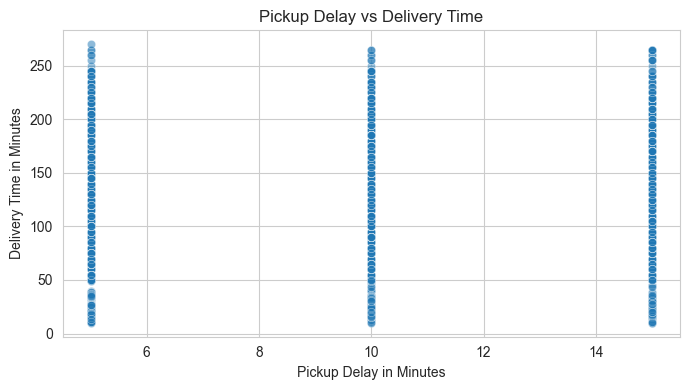

Pickup delay correlation: -0.006


In [20]:
pickup_check = df.dropna(subset=["pickup_delay_mins", "delivery_time"])

sample_pickup = pickup_check.sample(
    min(3000, len(pickup_check)),
    random_state=42
)

plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=sample_pickup,
    x="pickup_delay_mins",
    y="delivery_time",
    alpha=0.5
)
plt.title("Pickup Delay vs Delivery Time")
plt.xlabel("Pickup Delay in Minutes")
plt.ylabel("Delivery Time in Minutes")
plt.tight_layout()
plt.savefig("../visuals/pickup_delay_vs_delivery_time.png", dpi=300)
plt.show()

pickup_corr = pickup_check["pickup_delay_mins"].corr(pickup_check["delivery_time"])
print("Pickup delay correlation:", round(pickup_corr, 3))

Pickup delay is treated as a supporting operational metric.

Its relationship with delivery time is reviewed using both the scatter plot and correlation instead of assuming it as the main driver.

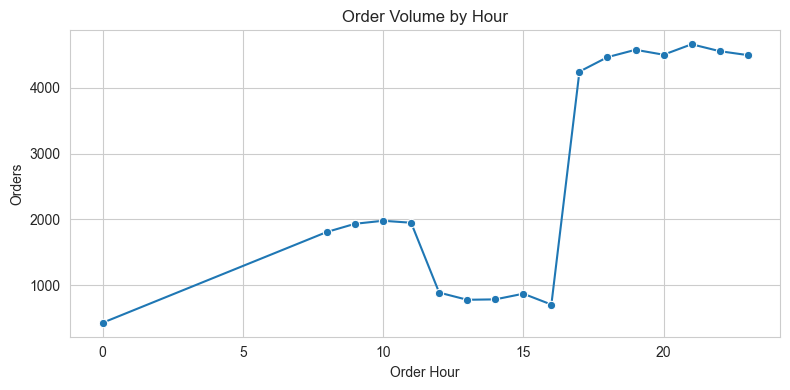

,order_hour,orders,avg_delivery_time,slow_delivery_rate
0,0.0,429,103.64,7.23
1,8.0,1810,93.04,1.49
2,9.0,1934,92.52,0.72
3,10.0,1980,93.02,1.06
4,11.0,1950,125.41,20.51
5,12.0,888,128.49,22.86
6,13.0,779,131.40,22.59
7,14.0,785,130.36,23.95
8,15.0,871,109.94,9.64
9,16.0,706,109.47,7.93


,peak_hour_flag,orders,avg_delivery_time,slow_delivery_rate
0,Non-Peak Hour,16630,107.93,9.84
1,Peak Hour,27018,135.37,31.21
2,Unknown,91,120.67,15.38


In [21]:
hour_summary = (
    df.groupby("order_hour")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

hour_summary["avg_delivery_time"] = hour_summary["avg_delivery_time"].round(2)
hour_summary["slow_delivery_rate"] = (hour_summary["slow_delivery_rate"] * 100).round(2)

plt.figure(figsize=(8, 4))
sns.lineplot(data=hour_summary, x="order_hour", y="orders", marker="o")
plt.title("Order Volume by Hour")
plt.xlabel("Order Hour")
plt.ylabel("Orders")
plt.tight_layout()
plt.savefig("../visuals/order_volume_by_hour.png", dpi=300)
plt.show()

peak_summary = (
    df.groupby("peak_hour_flag")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

peak_summary["avg_delivery_time"] = peak_summary["avg_delivery_time"].round(2)
peak_summary["slow_delivery_rate"] = (peak_summary["slow_delivery_rate"] * 100).round(2)

display(hour_summary)
display(peak_summary)

In [22]:
vehicle_summary = (
    df.groupby("vehicle")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

vehicle_summary["avg_delivery_time"] = vehicle_summary["avg_delivery_time"].round(2)
vehicle_summary["slow_delivery_rate"] = (vehicle_summary["slow_delivery_rate"] * 100).round(2)

display(vehicle_summary.sort_values("avg_delivery_time", ascending=False))

small_vehicle_groups = vehicle_summary[vehicle_summary["orders"] < 50]

if len(small_vehicle_groups) > 0:
    print("Note: Some vehicle groups have very small sample sizes and should not be over-interpreted.")
    display(small_vehicle_groups)


,vehicle,orders,avg_delivery_time,slow_delivery_rate
1,Motorcycle,25527,131.03,26.80
0,Bicycle,15,127.00,13.33
2,Scooter,14639,116.36,18.00
3,Van,3558,116.14,17.00


Note: Some vehicle groups have very small sample sizes and should not be over-interpreted.


,vehicle,orders,avg_delivery_time,slow_delivery_rate
0,Bicycle,15,127.0,13.33


In [23]:
rating_summary = (
    df.groupby("rating_group")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

rating_summary["avg_delivery_time"] = rating_summary["avg_delivery_time"].round(2)
rating_summary["slow_delivery_rate"] = (rating_summary["slow_delivery_rate"] * 100).round(2)

rating_summary


,rating_group,orders,avg_delivery_time,slow_delivery_rate
0,High Rating,18185,115.81,14.62
1,Low Rating,8062,166.45,63.45
2,Medium Rating,17492,115.21,13.21


## Baseline Model

I added one simple baseline model to check whether available operational fields can explain delivery time.

This is not the main part of the project. The main focus remains KPI analysis, slow-delivery patterns, and dashboard-ready reporting.

In [ ]:
model_features = [
    "traffic",
    "weather",
    "vehicle",
    "area",
    "category",
    "order_hour",
    "pickup_delay_mins",
    "distance_km"
]

model_df = analysis_df[model_features + ["delivery_time"]].dropna()

X = model_df[model_features]
y = model_df["delivery_time"]

categorical_features = ["traffic", "weather", "vehicle", "area", "category"]
numeric_features = ["order_hour", "pickup_delay_mins", "distance_km"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

baseline_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

model_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", baseline_model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_pipeline.fit(X_train, y_train)
predictions = model_pipeline.predict(X_test)

print("Rows used:", len(model_df))
print("MAE:", round(mean_absolute_error(y_test, predictions), 2))
print("R2 Score:", round(r2_score(y_test, predictions), 3))

## Final Insights and Recommendations

The final section summarizes the main operational patterns found in the analysis.

Recommendations are kept practical and limited to what the dataset can support.


In [ ]:
traffic_avg = df.groupby("traffic")["delivery_time"].mean().sort_values(ascending=False)
traffic_gap = traffic_avg.max() - traffic_avg.min()

risk_candidates = traffic_distance.query("orders >= 50").sort_values("slow_delivery_rate", ascending=False)
top_risk_group = risk_candidates.iloc[0] if len(risk_candidates) > 0 else None

print("Final Insights")
print("-" * 50)

print(f"1. The analysis covers {len(df):,} delivery records.")
print(f"2. Average delivery time is {df['delivery_time'].mean():.2f} minutes, with a median of {df['delivery_time'].median():.2f} minutes.")
print(f"3. Proxy slow-delivery rate is {df['slow_delivery_flag'].mean() * 100:.2f}% based on the 75th percentile threshold.")
print(f"4. Traffic groups show a delivery-time gap of {traffic_gap:.2f} minutes between the highest and lowest average groups.")

if top_risk_group is not None:
    print(
        "5. The highest observed risk group is",
        top_risk_group["traffic"],
        "traffic with",
        top_risk_group["distance_category"],
        "distance."
    )
else:
    print("5. No traffic-distance group had enough records for a reliable top-risk comparison.")

print(f"6. {df['distance_issue_flag'].sum():,} records were flagged for distance issues and excluded from distance-based analysis.")
print(f"7. Pickup delay is treated as a supporting metric based on the scatter plot and correlation review.")

In [ ]:
print("Recommendations")
print("-" * 50)

print("1. Monitor Jam or high-traffic deliveries with longer distance categories separately because these groups showed higher slow-delivery risk.")
print("2. Use the dashboard summary file to track slow-delivery rate by traffic, area, vehicle, distance category, and peak-hour flag.")
print("3. Review distance issue records separately before using them for distance-based decisions or route analysis.")
print("4. Treat small vehicle groups carefully because low record counts can create misleading averages.")
print("5. Keep pickup delay as a supporting KPI, but do not treat it as the main driver without stronger evidence.")
print("6. Use the proxy slow-delivery flag only for internal analysis because the dataset does not include actual SLA or promised delivery time.")
print("7. For future improvement, compare this analysis with actual promised delivery time, route data, and delivery partner capacity if those fields become available.")

In [ ]:
os.makedirs("../data/", exist_ok=True)
os.makedirs("../excel", exist_ok=True)

df.to_csv("../data/delivery_processed.csv", index=False)
kpi_summary.to_csv("../data/delivery_kpi_summary.csv", index=False)

print("Export completed.")

In [ ]:
df.shape